# Aula Prática, Lógica Fuzzy com Python

Controle da velocidade do ventilador em uma sala de aula inteligente

### Objetivo
Construir um sistema fuzzy capaz de definir a velocidade ideal de um ventilador com base em:

- temperatura da sala
- quantidade de alunos presentes

### Conceitos que serão trabalhados
- conjuntos fuzzy
- funções de pertinência
- fuzzificação
- regras fuzzy
- inferência
- defuzzificação

# Passo 0: Preparação do Ambiente
# No Google Colab, precisamos instalar a biblioteca scikit-fuzzy. 
# Se estiver rodando localmente no Jupyter e já tiver instalado, pode pular esta célula.

In [1]:
pip install numpy matplotlib scikit-fuzzy notebook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [isoduration]
Note: you may need to restart the kernel to use updated packages.


## Problema proposto

Imagine uma sala de aula inteligente.

Se a temperatura estiver alta e houver muitos alunos, o ventilador deve aumentar a velocidade.

Se a temperatura estiver baixa e houver poucos alunos, o ventilador pode funcionar devagar.

Na lógica clássica, algo seria apenas "quente" ou "não quente".

Na lógica fuzzy, um valor pode pertencer parcialmente a mais de uma categoria ao mesmo tempo.

## numpy
é usado para criar os intervalos numéricos das variáveis

## matplotlib.pyplot
é usado para exibir os gráficos

## skfuzzy
é a biblioteca que implementa funções e operações da lógica fuzzy

## control
é o módulo que permite criar variáveis linguísticas, regras e o sistema de inferência

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

## Definindo as variáveis do sistema

Nosso sistema terá:

### Entradas
- temperatura
- quantidade_alunos

### Saída
- velocidade_ventilador

In [5]:
temperatura = ctrl.Antecedent(np.arange(0, 41, 1), 'temperatura')
quantidade_alunos = ctrl.Antecedent(np.arange(0, 51, 1), 'quantidade_alunos')
velocidade_ventilador = ctrl.Consequent(np.arange(0, 101, 1), 'velocidade_ventilador')

np.arange(0, 41, 1)
cria os valores de 0 até 40 para temperatura

np.arange(0, 51, 1)
cria os valores de 0 até 50 para quantidade de alunos

np.arange(0, 101, 1)
cria os valores de 0 até 100 para a velocidade do ventilador

ctrl.Antecedent(...)
define uma variável de entrada do sistema fuzzy

ctrl.Consequent(...)
define uma variável de saída do sistema fuzzy


Exemplo: np.arange(0, 41, 1)

[0, 1, 2, 3, 4, ..., 39, 40]

Ou seja:

começa em 0
vai até antes de 41
anda de 1 em 1

Então:

0 é o valor inicial
41 é o limite superior, mas ele não entra
1 é o passo

## Criando os conjuntos fuzzy

Agora vamos criar os rótulos linguísticos para cada variável.

### Temperatura
- fria
- agradavel
- quente

### Quantidade de alunos
- poucos
- media
- muitos

### Velocidade do ventilador
- baixa
- media
- alta

In [6]:
temperatura['fria'] = fuzz.trimf(temperatura.universe, [0, 0, 20])
temperatura['agradavel'] = fuzz.trimf(temperatura.universe, [15, 22, 30])
temperatura['quente'] = fuzz.trimf(temperatura.universe, [25, 40, 40])

quantidade_alunos['poucos'] = fuzz.trimf(quantidade_alunos.universe, [0, 0, 20])
quantidade_alunos['media'] = fuzz.trimf(quantidade_alunos.universe, [10, 25, 40])
quantidade_alunos['muitos'] = fuzz.trimf(quantidade_alunos.universe, [30, 50, 50])

velocidade_ventilador['baixa'] = fuzz.trimf(velocidade_ventilador.universe, [0, 0, 40])
velocidade_ventilador['media'] = fuzz.trimf(velocidade_ventilador.universe, [20, 50, 80])
velocidade_ventilador['alta'] = fuzz.trimf(velocidade_ventilador.universe, [60, 100, 100])

## fuzz.trimf
cria uma função de pertinência triangular

temperatura['fria'] = fuzz.trimf(temperatura.universe, [0, 0, 20])

significa que:
a categoria “fria” começa forte nos valores baixos e vai perdendo pertinência até 20

Esses três números representam os pontos da função triangular. Ele representa a variável linguística

/opt/homebrew/anaconda3/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


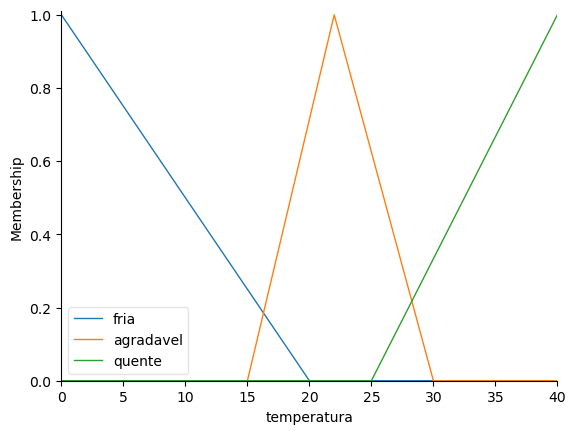

In [7]:
temperatura.view()
plt.show()

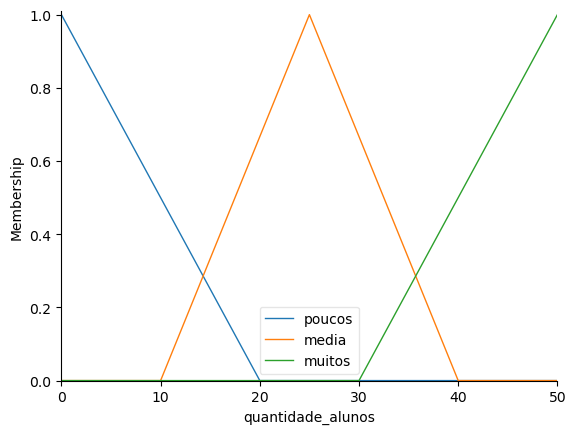

In [8]:
quantidade_alunos.view()
plt.show()

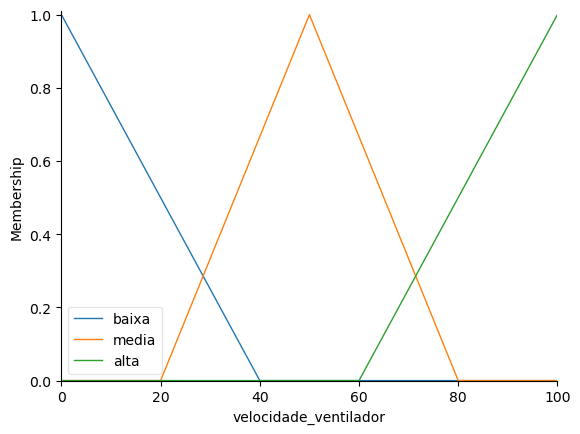

In [10]:
velocidade_ventilador.view()
plt.show()

## Criando as regras fuzzy

Agora vamos construir regras semelhantes ao raciocínio humano.

Exemplos:
- se a temperatura estiver fria e houver poucos alunos, a velocidade deve ser baixa
- se a temperatura estiver quente ou houver muitos alunos, a velocidade deve ser alta

In [11]:
regra_1 = ctrl.Rule(temperatura['fria'] & quantidade_alunos['poucos'], velocidade_ventilador['baixa'])
regra_2 = ctrl.Rule(temperatura['agradavel'] & quantidade_alunos['media'], velocidade_ventilador['media'])
regra_3 = ctrl.Rule(temperatura['quente'] | quantidade_alunos['muitos'], velocidade_ventilador['alta'])
regra_4 = ctrl.Rule(temperatura['quente'] & quantidade_alunos['muitos'], velocidade_ventilador['alta'])
regra_5 = ctrl.Rule(temperatura['fria'] & quantidade_alunos['muitos'], velocidade_ventilador['media'])

ctrl.Rule
cria uma regra fuzzy

& significa E

| significa OU

Exemplo:
regra_1 = ctrl.Rule(temperatura['fria'] & quantidade_alunos['poucos'], velocidade_ventilador['baixa'])

se a temperatura estiver fria E houver poucos alunos, então a velocidade do ventilador deve ser baixa

## Montando o sistema fuzzy

Agora vamos reunir todas as regras e criar um simulador.

In [13]:
sistema_controle = ctrl.ControlSystem([regra_1, regra_2, regra_3, regra_4, regra_5])
simulador = ctrl.ControlSystemSimulation(sistema_controle)

ctrl.ControlSystem(...)
agrupa todas as regras em um sistema de controle fuzzy

ctrl.ControlSystemSimulation(...)
cria o ambiente de simulação (inferência) no qual vamos inserir valores e obter respostas

## Testando o sistema

Vamos simular o seguinte cenário:

- temperatura = 28
- quantidade_alunos = 35

In [14]:
simulador.input['temperatura'] = 28
simulador.input['quantidade_alunos'] = 35

simulador.compute()

print(f"Velocidade do ventilador: {simulador.output['velocidade_ventilador']:.2f}")

Velocidade do ventilador: 61.84


simulador.input[...]
define os valores de entrada

simulador.compute()
manda o sistema processar as regras fuzzy

simulador.output[...]
retorna o valor final numérico da saída

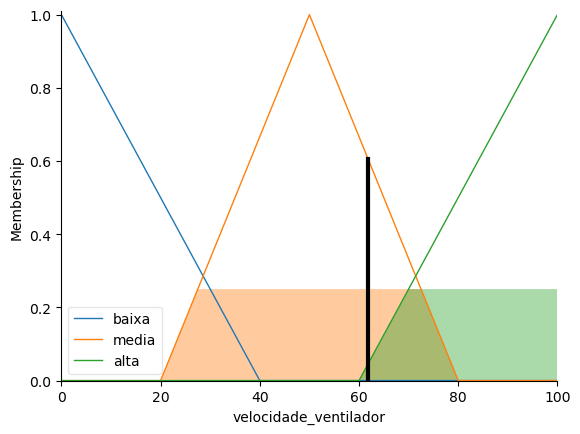

In [15]:
velocidade_ventilador.view(sim=simulador)
plt.show()

Gráfico mostra visualmente como ficou a saída fuzzy e o ponto final obtido após a defuzzificação.

## Testando vários cenários

Agora vamos observar como o sistema se comporta em diferentes situações.

In [16]:
cenarios = [
    (18, 10),
    (22, 20),
    (27, 15),
    (30, 35),
    (35, 45)
]

for temperatura_sala, alunos_presentes in cenarios:
    simulador.input['temperatura'] = temperatura_sala
    simulador.input['quantidade_alunos'] = alunos_presentes
    simulador.compute()
    
    print(
        f"Temperatura: {temperatura_sala}°C | "
        f"Quantidade de alunos: {alunos_presentes} | "
        f"Velocidade do ventilador: {simulador.output['velocidade_ventilador']:.2f}"
    )

Temperatura: 18°C | Quantidade de alunos: 10 | Velocidade do ventilador: 19.02
Temperatura: 22°C | Quantidade de alunos: 20 | Velocidade do ventilador: 50.00
Temperatura: 27°C | Quantidade de alunos: 15 | Velocidade do ventilador: 55.83
Temperatura: 30°C | Quantidade de alunos: 35 | Velocidade do ventilador: 83.11
Temperatura: 35°C | Quantidade de alunos: 45 | Velocidade do ventilador: 86.00


## Atividade

1. Altere a função de pertinência da categoria "quente"
2. Crie uma nova regra fuzzy
3. Teste três novos cenários
4. Explique se os resultados ficaram coerentes

In [17]:
import os
os.getcwd()

'/Users/wmalv'